# Inverted Pendulum: Frequency Domain Methods for Controller Design

Key Python commands used in this tutorial are: [`control.TransferFunction`](https://python-control.readthedocs.io/en/latest/generated/control.TransferFunction.html),[`control.bode`](https://python-control.readthedocs.io/en/latest/generated/control.bode.html),[`control.nyquist`](https://python-control.readthedocs.io/en/latest/generated/control.nyquist.html),[`control.feedback`](https://python-control.readthedocs.io/en/latest/generated/control.feedback.html),

[`control.impulse_response`](https://python-control.readthedocs.io/en/latest/generated/control.impulse_response.html)

In this page we will design a controller for the inverted pendulum system using a frequency response design method. In the design process we will assume a single-input, single-output plant as described by the following transfer function. Otherwise stated, we will attempt to control the pendulum's angle without regard for the cart's position.

$$P_{pend}(s) = \frac{\Phi(s)}{U(s)}=\frac{\frac{ml}{q}s}{s^3+\frac{b(I+ml^2)}{q}s^2-\frac{(M+m)mgl}{q}s-\frac{bmgl}{q}} \qquad [ \frac{rad}{N}]$$

where,

$$q = (M+m)(I+ml^2) - (ml)^2$$

The controller we are designing will specifically attempt to maintain the pendulum vertically upward when the cart is subjected to a 1-Nsec impulse. Under these conditions, the design criteria are:

* Settling time of less than 5 seconds * Pendulum should not move more than 0.05 radians away from the vertical

For the original problem setup and the derivation of the above transfer function, please consult the [Inverted Pendulum: System Modeling](InvertedPendulum_SystemModeling.ipynb) page.

**Note:** Applying a frequency response design approach is relatively challenging in the case of this example because the open-loop system is unstable. That is, the open-loop transfer function has a pole in the right-half complex plane. For this reason, attempting this example is not recommended if you are just attempting to learn the basics of applying frequency response techniques. This problem is better suited for more advanced students who wish to learn about some nuances of the frequency response design approach.

## System structure

The structure of the controller for this problem is a little different than the standard control problems you may be used to. Since we are attempting to control the pendulum's position, which should return to the vertical after the initial disturbance, the reference signal we are tracking should be zero. This type of situation is often referred to as a regulator problem. The external force applied to the cart can be considered as an impulsive disturbance. The schematic for this problem is depicted below.

![feedback_pend.png](figures/feedback_pend.png)

You may find it easier to analyze and design for this system if we first rearrange the schematic as follows.

![feedback_pend2.png](figures/feedback_pend2.png)

The resulting transfer function $T(s)$ for the closed-loop system from an input of force $F$ to an output of pendulum angle $\phi$ is then determined to be the following.

$$ T(s) = \frac{\Phi(s)}{F(s)} = \frac{P_{pend}(s)}{1 + P_{pend}(s)C(s)} $$

Before we begin designing our controller, we first need to define our plant within Python. Create a new code cell and type in the following commands to create the plant model (refer to the main problem for the details of getting these commands).



In [1]:
import control
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(
    rc={
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "figure.figsize": (4 * 1.618, 4),
        "figure.dpi": 200,
    }
)

M = 0.5
m = 0.2
b = 0.1
I = 0.006
g = 9.8
l = 0.3
q = (M + m) * (I + m * l**2) - (m * l) ** 2
s = control.TransferFunction.s

P_pend = (m * l * s / q) / (s**3 + (b * (I + m * l**2)) * s**2 / q - ((M + m) * m * g * l) * s / q - b * m * g * l / q)

As mentioned above, this system is unstable without control. We can prove this to ourselves by examining the poles and zeros of the system. The following code will show the poles and zeros:



In [2]:
zeros, poles = control.pzmap(P_pend, plot=False)
print("Zeros:", zeros)
print("Poles:", poles)

Zeros: [ 5.56510758+0.j -5.60409413+0.j -0.14283164+0.j]
Poles: [0.+0.j]


/projects/UMich_Controls_Tutorials_Python/venv_UMich_Controls_Tutorials_Python/lib/python3.12/site-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


## Closed-loop response without compensation

We will now examine the response of the closed-loop system without compensation before we begin to design our controller. In general, when dealing with nonminimum-phase systems it is preferable to analyze relative stability using the Nyquist plot of the open-loop transfer function. The Nyquist plot is also preferred when analyzing higher-order systems.

The Nyquist stability criterion states:

$$ Z = P + N $$

Where $Z$ is the number of closed-loop poles in the right-half plane, $P$ is the number of open-loop poles in the right-half plane, and $N$ is the number of clockwise encirclements of the point -1 by the open-loop Nyquist plot.

From our previous discussion we know that our system has one open-loop pole in the right-half plane ($P$ = 1) and from examination of the open-loop Nyquist plot we can see that there are no encirclements of the point -1 ($N$ = 0). Therefore, $Z$ = 0 + 1 = 1 and the closed-loop system has 1 pole in the right-half plane indicating that it is indeed unstable.

## Closed-loop response with compensation

Since the closed-loop system is unstable without compensation, we need to use our controller to stabilize the system and meet the given requirements. Our first step will be to add an integrator to cancel the zero at the origin. Even with the addition of this integrator, the closed-loop system is still unstable. We need to add phase in order to get a counterclockwise encirclement. We will do this by adding zeros to our controller.

After some design iteration, the following controller satisfies the given requirements:

$$ C(s) = 35\frac{(s+1)(s+2)}{s} $$

This is a PID controller with two zeros. Let's implement this controller and examine the closed-loop response:



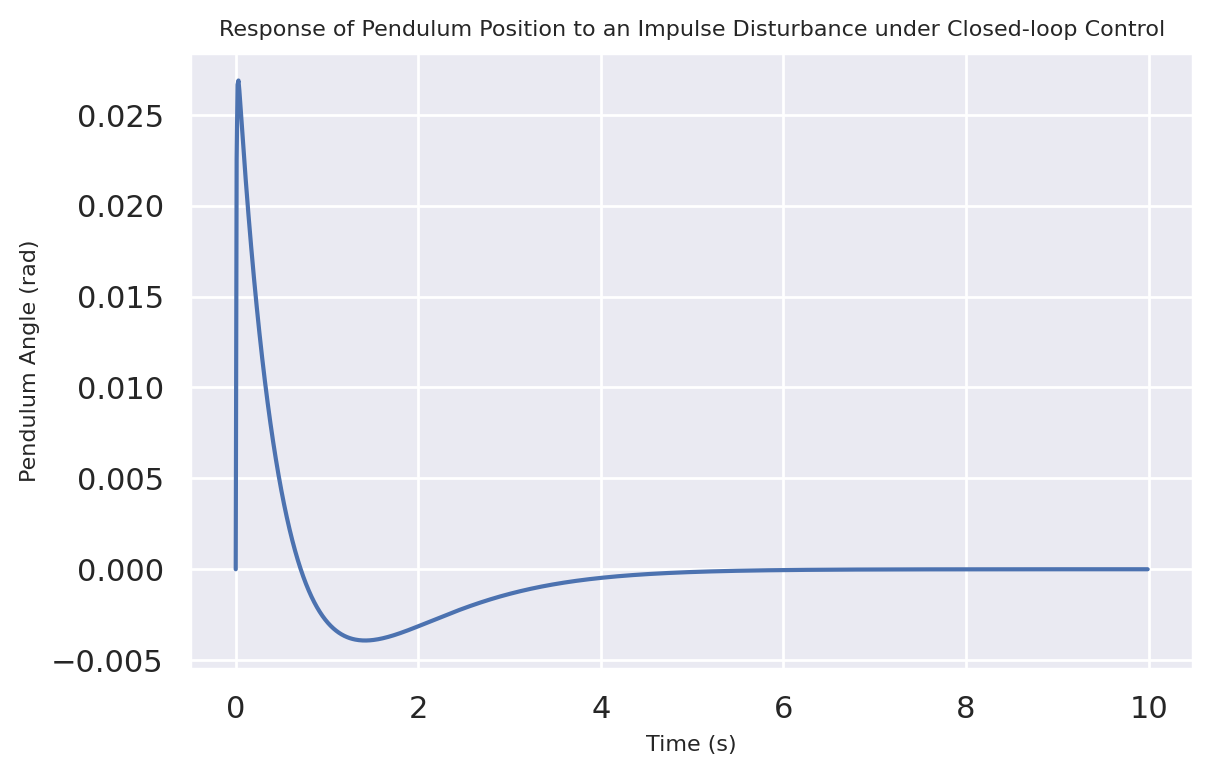

In [3]:
K = 35
C = K * (s + 1) * (s + 2) / s
T = control.feedback(P_pend, C)
t = np.arange(0, 10, 0.01)
T_resp, yout = control.impulse_response(T, T=t)
plt.plot(T_resp, yout)
plt.title("Response of Pendulum Position to an Impulse Disturbance under Closed-loop Control")
plt.xlabel("Time (s)")
plt.ylabel("Pendulum Angle (rad)")
plt.grid("on")
plt.show()

From examination of the figure above, it is apparent that the response of the system is now stable and meets the design requirements.

## What happens to the cart's position?

At the beginning of this page, a block diagram for the inverted pendulum system was given. The diagram was not entirely complete. The block representing the response of the cart's position $x$ was not included because that variable is not being controlled. It is interesting though, to see what is happening to the cart's position when the controller for the pendulum's angle is in place. To see this we need to consider the full system block diagram.

The closed-loop transfer function $T_2(s)$ from an input force applied to the cart to an output of cart position is, therefore, given by the following.

$$ T_2(s) = \frac{X(s)}{F(s)} = \frac{P_{cart}(s)}{1 + P_{pend}(s)C(s)}$$

Referring to the [Inverted Pendulum: System Modeling](InvertedPendulum_SystemModeling.ipynb) page, the transfer function for $P_{cart}(s)$ is defined as follows.

$$P_{cart}(s) = \frac{X(s)}{U(s)} = \frac{ \frac{ (I+ml^2)s^2 - gml } {q} }{s^4+\frac{b(I+ml^2)}{q}s^3-\frac{(M+m)mgl}{q}s^2-\frac{bmgl}{q}s} \qquad [ \frac{m}{N}] $$

where,

$$q=[(M+m)(I+ml^2)-(ml)^2]$$

Adding the following commands to your code cell (presuming $P_{pend}(s)$ and $C(s)$ are still defined) will generate the response of the cart's position to the same impulsive disturbance we have been considering.



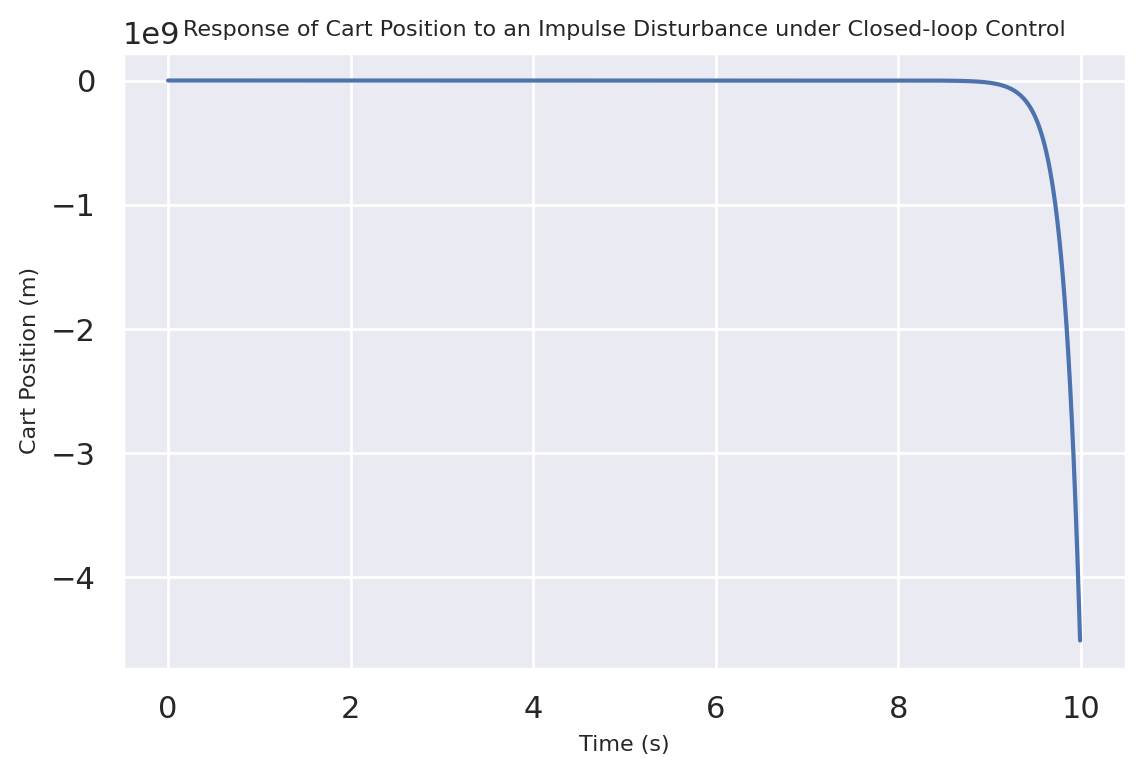

In [4]:
P_cart = (((I + m * l**2) / q) * s**2 - (m * g * l / q)) / (
    s**4 + (b * (I + m * l**2)) * s**3 / q - ((M + m) * m * g * l) * s**2 / q - b * m * g * l * s / q
)
T2 = control.feedback(1, P_pend * C) * P_cart
t = np.arange(0, 10, 0.01)
T_resp, yout = control.impulse_response(T2, T=t)
plt.plot(T_resp, yout)
plt.title("Response of Cart Position to an Impulse Disturbance under Closed-loop Control")
plt.xlabel("Time (s)")
plt.ylabel("Cart Position (m)")
plt.grid("on")
plt.show()

As you can see, the cart moves in the negative direction and stabilizes at about -0.14 meters. This design might work pretty well for the actual controller, assuming that the cart had that much room to move. Keep in mind that this was pure luck. We did not design our controller to stabilize the cart's position, the fact that it does is merely a fortunate side effect.

